<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
#!pip install pandas

In [3]:
#!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name
FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [8]:
QUERY = """SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL;
"""
bp_comp = pd.read_sql_query(QUERY, conn)
bp_comp['CompTotal'].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

In [9]:
q1 = bp_comp['CompTotal'].quantile(0.25)
q3 = bp_comp['CompTotal'].quantile(0.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
comp_no_outliers = bp_comp[bp_comp['CompTotal'] <= upper_bounds]
comp_no_outliers.describe()

,CompTotal
count,27864.000000
mean,117182.605369
std,99970.300622
min,0.000000
25%,50000.000000
50%,88000.000000
75%,150000.000000
max,535000.000000


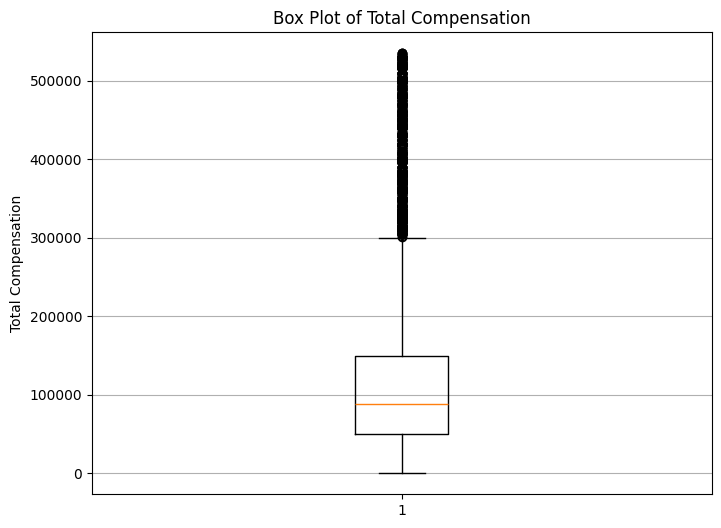

In [10]:
plt.figure(figsize = (8, 6))
plt.boxplot(comp_no_outliers['CompTotal'])
plt.grid(axis = 'y')
plt.ylabel('Total Compensation')
plt.title('Box Plot of Total Compensation')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [11]:
QUERY = """SELECT Age
FROM main
WHERE Age IS NOT NULL
AND Age != 'Prefer not to say';
"""
bp_age = pd.read_sql_query(QUERY, conn)

In [12]:
bp_age = bp_age.dropna()
bp_age['Age'].unique()

<ArrowStringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  '65 years or older']
Length: 7, dtype: str

In [13]:
bp_age['Age'] = bp_age['Age'].map({'Under 18 years old': 16,
                                   '65 years or older': 67,
                                   '25-34 years old': 29,
                                   '35-44 years old': 39,
                                   '18-24 years old': 21,
                                   '45-54 years old': 49,
                                   '55-64 years old': 60})

In [14]:
bp_age['Age'].describe()

count    65115.000000
mean        32.645750
std         11.121587
min         16.000000
25%         21.000000
50%         29.000000
75%         39.000000
max         67.000000
Name: Age, dtype: float64

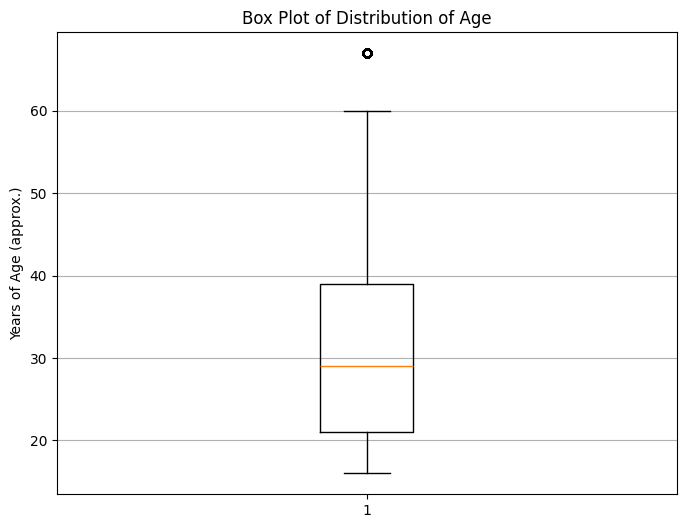

In [15]:
plt.figure(figsize = (8, 6))
plt.boxplot(bp_age['Age'])
plt.grid(axis = 'y')
plt.ylabel('Years of Age (approx.)')
plt.title('Box Plot of Distribution of Age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [16]:
QUERY = """SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL
AND Age IS NOT NULL
AND Age != 'Prefer not to say'
AND CompTotal < 535000;
"""
bp_comp_age = pd.read_sql_query(QUERY, conn)
bp_comp_age.head() # have removed outliers via previously performed IQR method

,CompTotal,Age
0,28000.0,25-34 years old
1,85000.0,35-44 years old
2,50000.0,35-44 years old
3,110000.0,25-34 years old
4,126420.0,35-44 years old


In [17]:
bp_comp_age['Age'].unique()

<ArrowStringArray>
[   '25-34 years old',    '35-44 years old',    '45-54 years old',
    '55-64 years old',    '18-24 years old',  '65 years or older',
 'Under 18 years old']
Length: 7, dtype: str

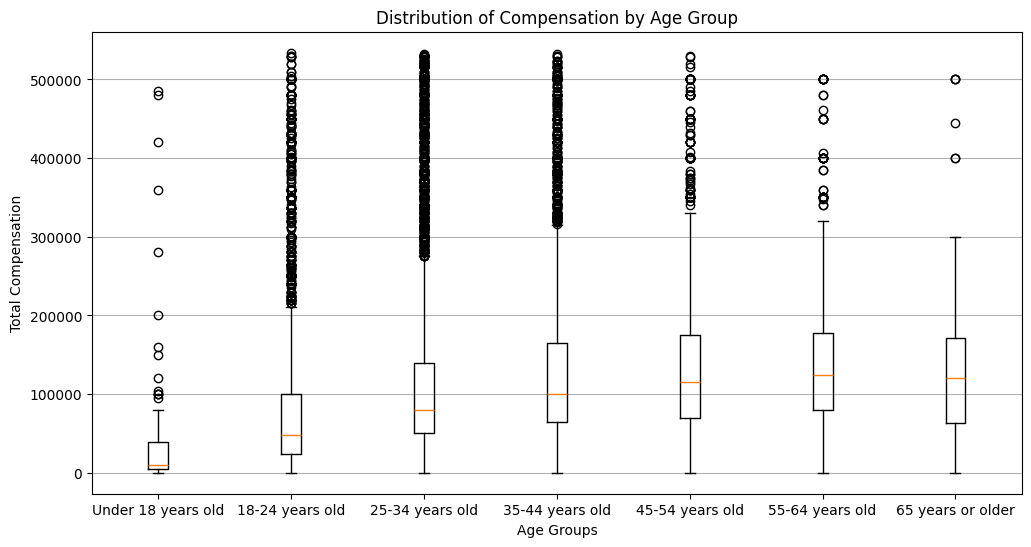

In [18]:
age_groups = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
pos = 0

plt.figure(figsize = (12, 6))

for age in age_groups:
    pos = pos+1
    plt.boxplot(bp_comp_age.loc[bp_comp_age['Age'] == age, 'CompTotal'],
                positions = [pos],
                tick_labels = [age])
plt.grid(axis = 'y')
plt.ylabel('Total Compensation')
plt.xlabel('Age Groups')
plt.title('Distribution of Compensation by Age Group')
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [19]:
QUERY = """SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND CompTotal < 535000
AND JobSatPoints_6 IS NOT NULL;
"""
bp_comp_job6 = pd.read_sql_query(QUERY, conn)
bp_comp_job6.head()

,CompTotal,JobSatPoints_6
0,85000.0,0.0
1,110000.0,20.0
2,126420.0,30.0
3,195000.0,30.0
4,74000.0,25.0


In [20]:
bins = [0, 50, 75, 100]
labels = ['Low', 'Medium', 'High']

bp_comp_job6['JobSat'] = pd.cut(bp_comp_job6['JobSatPoints_6'], bins = bins, labels = labels, include_lowest = True)
bp_comp_job6

,CompTotal,JobSatPoints_6,JobSat
0,85000.0,0.0,Low
1,110000.0,20.0,Low
2,126420.0,30.0,Low
3,195000.0,30.0,Low
4,74000.0,25.0,Low
...,...,...,...
18417,40000.0,20.0,Low
18418,46000.0,50.0,Low
18419,81600.0,20.0,Low
18420,500000.0,0.0,Low


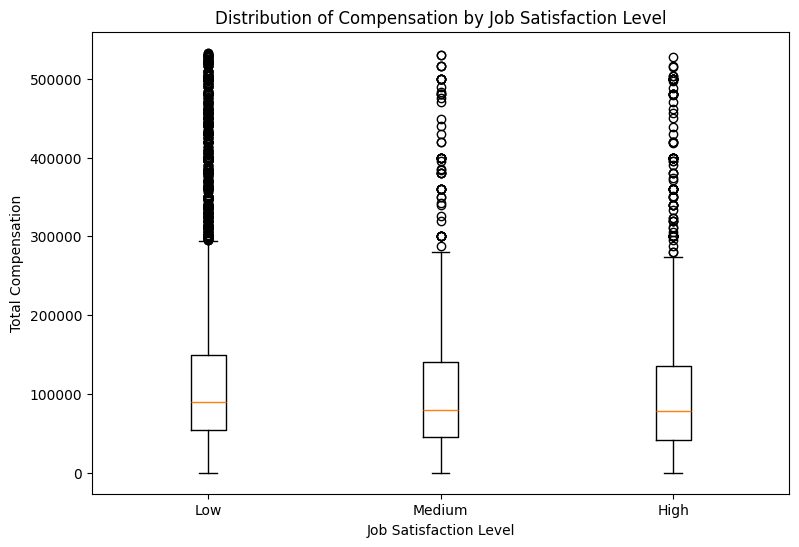

In [21]:
plt.figure(figsize = (9, 6))
pos = 0
for sat in labels:
    pos = pos + 1
    plt.boxplot(bp_comp_job6.loc[bp_comp_job6['JobSat'] == sat, 'CompTotal'],
                positions = [pos],
                tick_labels = [sat])
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Total Compensation')
plt.title('Distribution of Compensation by Job Satisfaction Level')
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [22]:
QUERY = """SELECT ConvertedCompYearly, DevType
FROM main
WHERE ConvertedCompYearly IS NOT NULL
AND DevType IS NOT NULL;
"""
bp_comp_dev = pd.read_sql_query(QUERY, conn)
bp_comp_dev['ConvertedCompYearly'].describe()

count    2.340300e+04
mean     8.616127e+04
std      1.868695e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079400e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [23]:
q3 = bp_comp_dev['ConvertedCompYearly'].quantile(0.75)
q1 = bp_comp_dev['ConvertedCompYearly'].quantile(0.25)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
bp_comp_dev = bp_comp_dev[bp_comp_dev['ConvertedCompYearly'] <= upper_bounds] # dropping outliers to make data more readable

In [24]:
top_5_dev = list(bp_comp_dev['DevType'].value_counts().head(5).index)
top_5_dev

['Developer, full-stack',
 'Developer, back-end',
 'Developer, front-end',
 'Developer, desktop or enterprise applications',
 'Developer, mobile']

In [25]:
rows = bp_comp_dev.loc[bp_comp_dev['DevType'].isin(top_5_dev) == False] # making list of rows that do not contain top 5 dev types
bp_comp_dev = bp_comp_dev.drop(rows.index) # dropping indices of rows without top 5 dev types
bp_comp_dev['DevType'].value_counts()

DevType
Developer, full-stack                            8069
Developer, back-end                              4524
Developer, front-end                             1387
Developer, desktop or enterprise applications    1025
Developer, mobile                                 783
Name: count, dtype: int64

In [26]:
bp_comp_dev.head()

,ConvertedCompYearly,DevType
3,53703.0,"Developer, back-end"
7,195000.0,"Developer, full-stack"
8,44586.0,"Developer, full-stack"
10,184712.0,"Developer, back-end"
11,79481.0,"Developer, full-stack"


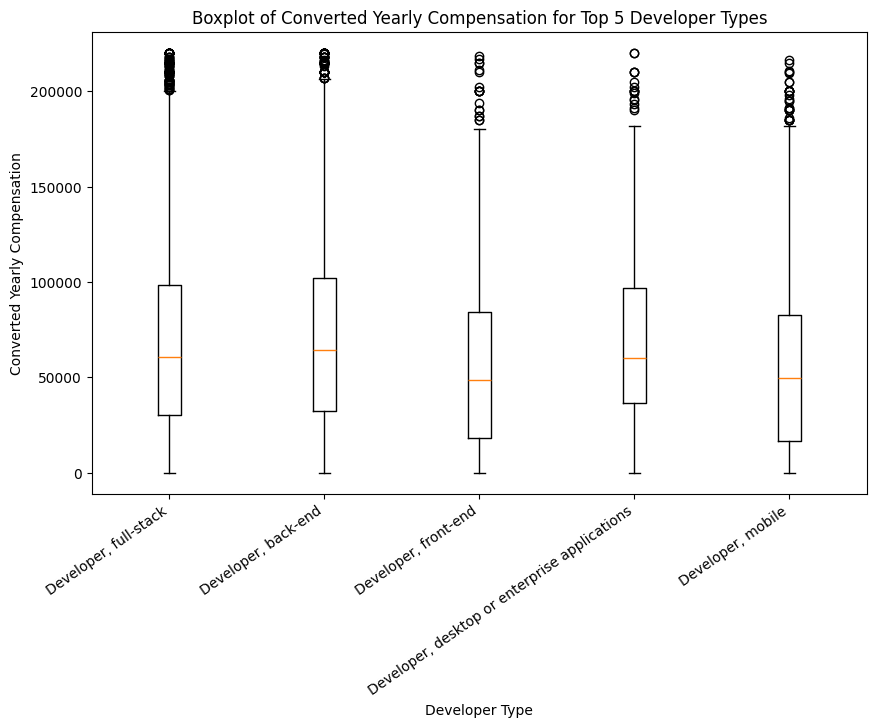

In [27]:
plt.figure(figsize = (10, 6))
pos = 0

for dev in top_5_dev:
    pos = pos + 1
    plt.boxplot(bp_comp_dev.loc[bp_comp_dev['DevType'] == dev, 'ConvertedCompYearly'],
                positions = [pos],
                tick_labels = [dev])
plt.ylabel('Converted Yearly Compensation')
plt.xlabel('Developer Type')
plt.xticks(rotation = 35, ha = 'right')
plt.title('Boxplot of Converted Yearly Compensation for Top 5 Developer Types')
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [28]:
QUERY = """SELECT ConvertedCompYearly, Country
FROM main
WHERE ConvertedCompYearly IS NOT NULL
AND Country IS NOT NULL;
"""
bp_comp_country = pd.read_sql_query(QUERY, conn)
bp_comp_country.head()

,ConvertedCompYearly,Country
0,7322.0,Pakistan
1,30074.0,Austria
2,91295.0,Turkey
3,53703.0,France
4,110000.0,United States of America


In [29]:
top_5_cntry = list(bp_comp_country['Country'].value_counts().head(5).index)
rows = bp_comp_country.loc[bp_comp_country['Country'].isin(top_5_cntry) == False]
bp_comp_country = bp_comp_country.drop(rows.index)
bp_comp_country.head()

,ConvertedCompYearly,Country
4,110000.0,United States of America
5,161044.0,United Kingdom of Great Britain and Northern I...
6,121018.0,United Kingdom of Great Britain and Northern I...
7,195000.0,United States of America
10,184712.0,United Kingdom of Great Britain and Northern I...


In [30]:
q3 = bp_comp_dev['ConvertedCompYearly'].quantile(0.75)
q1 = bp_comp_dev['ConvertedCompYearly'].quantile(0.25)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
bp_comp_country = bp_comp_country[bp_comp_country['ConvertedCompYearly'] <= upper_bounds] # dropping outliers to make data more readable

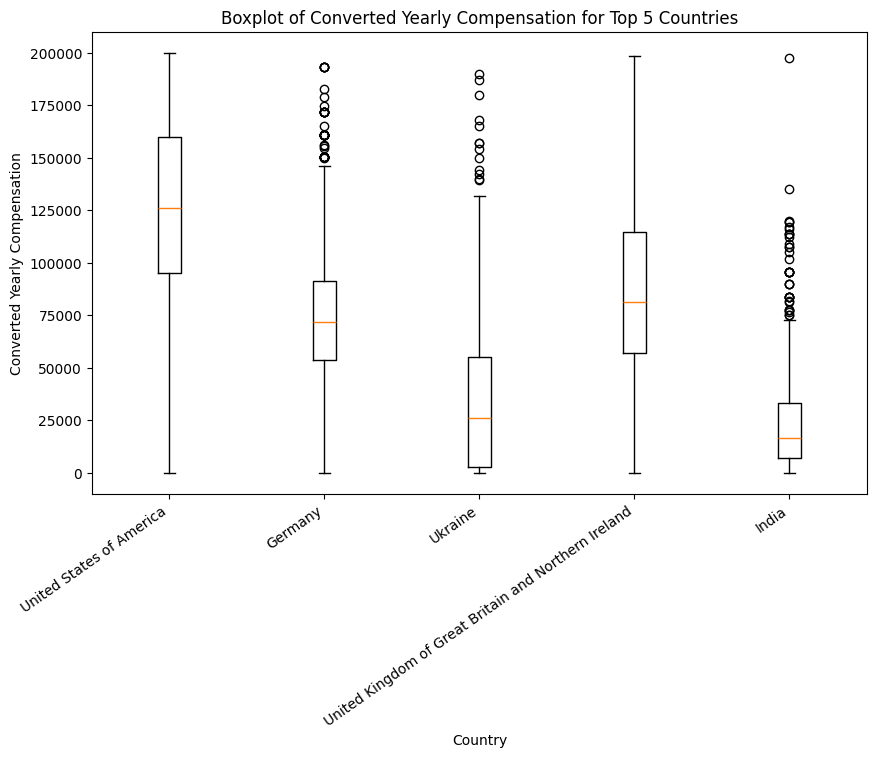

In [31]:
plt.figure(figsize = (10, 6))
pos = 0

for country in top_5_cntry:
    pos = pos + 1
    plt.boxplot(bp_comp_country.loc[bp_comp_country['Country'] == country, 'ConvertedCompYearly'],
                positions = [pos],
                tick_labels = [country])
plt.ylabel('Converted Yearly Compensation')
plt.xlabel('Country')
plt.xticks(rotation = 35, ha = 'right')
plt.title('Boxplot of Converted Yearly Compensation for Top 5 Countries')
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [32]:
QUERY = """SELECT CompTotal, Employment
FROM main
WHERE CompTotal IS NOT NULL
AND Employment IS NOT NULL;
"""
bp_comp_emp = pd.read_sql_query(QUERY, conn)
bp_comp_emp.head()

,CompTotal,Employment
0,2040000.0,"Employed, full-time;Student, full-time;Indepen..."
1,28000.0,"Employed, full-time"
2,85000.0,"Employed, full-time"
3,50000.0,"Independent contractor, freelancer, or self-em..."
4,110000.0,"Employed, full-time;Student, part-time"


In [33]:
q3 = bp_comp_emp['CompTotal'].quantile(0.75)
q1 = bp_comp_emp['CompTotal'].quantile(0.25)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
bp_comp_emp = bp_comp_emp[bp_comp_emp['CompTotal'] <= upper_bounds] # dropping outliers to make data more readable

In [34]:
bp_comp_emp['Employment'].value_counts().head()

Employment
Employed, full-time                                                         20783
Independent contractor, freelancer, or self-employed                         2048
Employed, full-time;Independent contractor, freelancer, or self-employed     1932
Employed, part-time                                                           577
Employed, full-time;Student, part-time                                        462
Name: count, dtype: int64

In [35]:
emp_list = list(bp_comp_emp['Employment'].value_counts().head().index) # making list to keep top 5 responses as there are way too many
rows = bp_comp_emp.loc[bp_comp_emp['Employment'].isin(emp_list) == False] # making list of indices to remove
bp_comp_emp = bp_comp_emp.drop(rows.index) # dropping indices of rows not containing top 5 responses

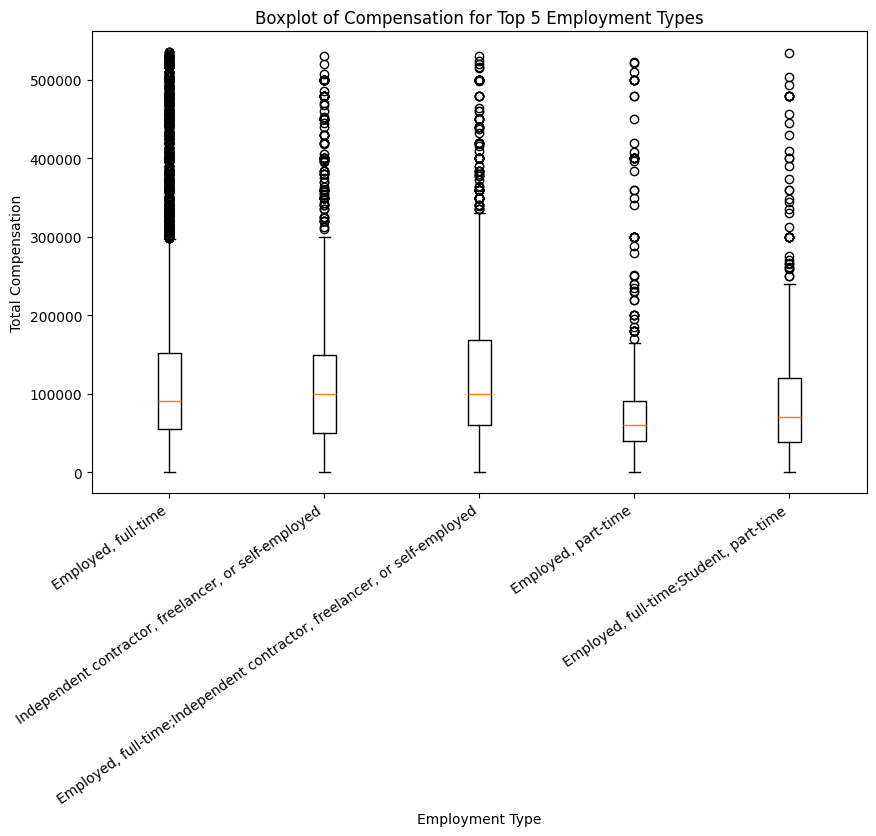

In [36]:
plt.figure(figsize = (10, 6))
pos = 0

for emp in emp_list:
    pos = pos + 1
    plt.boxplot(bp_comp_emp.loc[bp_comp_emp['Employment'] == emp, 'CompTotal'],
                positions = [pos],
                tick_labels = [emp])
plt.ylabel('Total Compensation')
plt.xlabel('Employment Type')
plt.xticks(rotation = 35, ha = 'right')
plt.title('Boxplot of Compensation for Top 5 Employment Types')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [37]:
QUERY = """SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
"""
bp_code_jobsat = pd.read_sql_query(QUERY, conn)
bp_code_jobsat.head()

,YearsCodePro,JobSatPoints_6
0,17,0.0
1,12,30.0
2,27,0.0
3,10,60.0
4,Less than 1 year,100.0


In [38]:
bp_code_jobsat['YearsCodePro'].unique() # verifying values in column for plotting

<ArrowStringArray>
[                '17',                 '12',                 '27',
                 '10',   'Less than 1 year',                 '18',
                 '15',                  '6',                  '7',
                 '16',                 '14',                  '4',
                  '8',                  '2',                 '29',
                  '5',                 '30',                  '1',
                 '25',                 '24',                 '26',
                  '9',                 '20',                 '37',
                 '11',                  '3',                 '13',
                 '19',                 '21',                 '23',
                 '34',                 '28',                 '32',
                 '22',                 '33',                 '40',
                 '39',                 '31',                 '35',
                 '41',                 '38', 'More than 50 years',
                 '36',                 '43'

In [39]:
bp_code_jobsat['YearsCodePro'] = bp_code_jobsat['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
bp_code_jobsat['YearsCodePro'] = bp_code_jobsat['YearsCodePro'].astype(int)

In [40]:
bins = [0, 50, 75, 100]
labels = ['Low', 'Medium', 'High']

bp_code_jobsat['JobSat'] = pd.cut(bp_code_jobsat['JobSatPoints_6'], bins = bins, labels = labels, include_lowest = True)

In [41]:
bp_code_jobsat.head()

,YearsCodePro,JobSatPoints_6,JobSat
0,17,0.0,Low
1,12,30.0,Low
2,27,0.0,Low
3,10,60.0,Medium
4,0,100.0,High


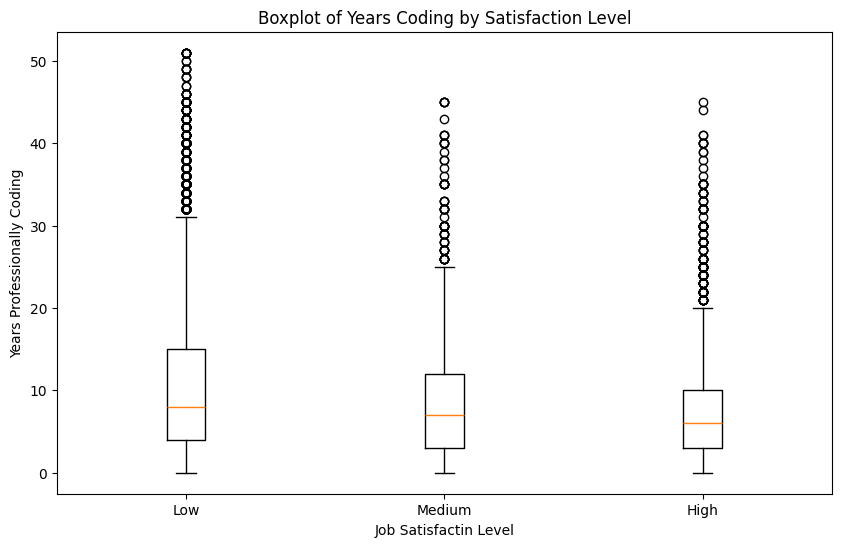

In [42]:
plt.figure(figsize = (10, 6))
pos = 0

for sat in labels:
    pos = pos + 1
    plt.boxplot(bp_code_jobsat.loc[bp_code_jobsat['JobSat'] == sat, 'YearsCodePro'],
                positions = [pos],
                tick_labels = [sat])
plt.ylabel('Years Professionally Coding')
plt.xlabel('Job Satisfactin Level')
plt.title('Boxplot of Years Coding by Satisfaction Level')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [43]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
